# Attestation timings within committee - missed slots

#### Maria Silva, July 2025


## 1. Imports

In [6]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [7]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [8]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Load data

#### Attestations

In [9]:
missed_atts_file = os.path.join(repo_dir, "data", "missed_slots_13097344_13147744", "sample_atts.parquet")
atts_df = pd.read_parquet(missed_atts_file)
atts_df["atts_prop_time_ms"] = atts_df["atts_arrival_time_ms"]-4000
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4135721 entries, 0 to 4135720
Data columns (total 7 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   slot                  int64 
 1   node_name             object
 2   node_country          object
 3   atts_validator        int64 
 4   atts_subnet           object
 5   atts_arrival_time_ms  int64 
 6   atts_prop_time_ms     int64 
dtypes: int64(4), object(3)
memory usage: 220.9+ MB


#### Validator info

In [10]:
val_file = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
val_df = pd.read_parquet(val_file)
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2073612 entries, 0 to 2073611
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   index   int64 
 1   entity  object
dtypes: int64(1), object(1)
memory usage: 31.6+ MB


#### Join data and process

In [11]:
# Join
df = (
    atts_df.merge(val_df, right_on="index", left_on="atts_validator", how="left")
    .drop(columns=["index"])
    .fillna({"entity": "unknown"})
)
# Group low cardinality entities into "other" category
entity_counts = df["entity"].value_counts()/len(df)
df = df.merge(entity_counts, left_on="entity", right_index=True)
df["entity"] = np.where(df["count"]>0.01, df["entity"], "other")
# Print info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4135721 entries, 0 to 4135720
Data columns (total 9 columns):
 #   Column                Dtype  
---  ------                -----  
 0   slot                  int64  
 1   node_name             object 
 2   node_country          object 
 3   atts_validator        int64  
 4   atts_subnet           object 
 5   atts_arrival_time_ms  int64  
 6   atts_prop_time_ms     int64  
 7   entity                object 
 8   count                 float64
dtypes: float64(1), int64(4), object(4)
memory usage: 284.0+ MB


In [12]:
df["slot"].nunique()

385

In [13]:
df["node_name"].sort_values().unique()

array(['ethpandaops/mainnet/xatu-tysm-ams3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-005-subnets-0-1'],
      dtype=object)

## 3. Overall distribution

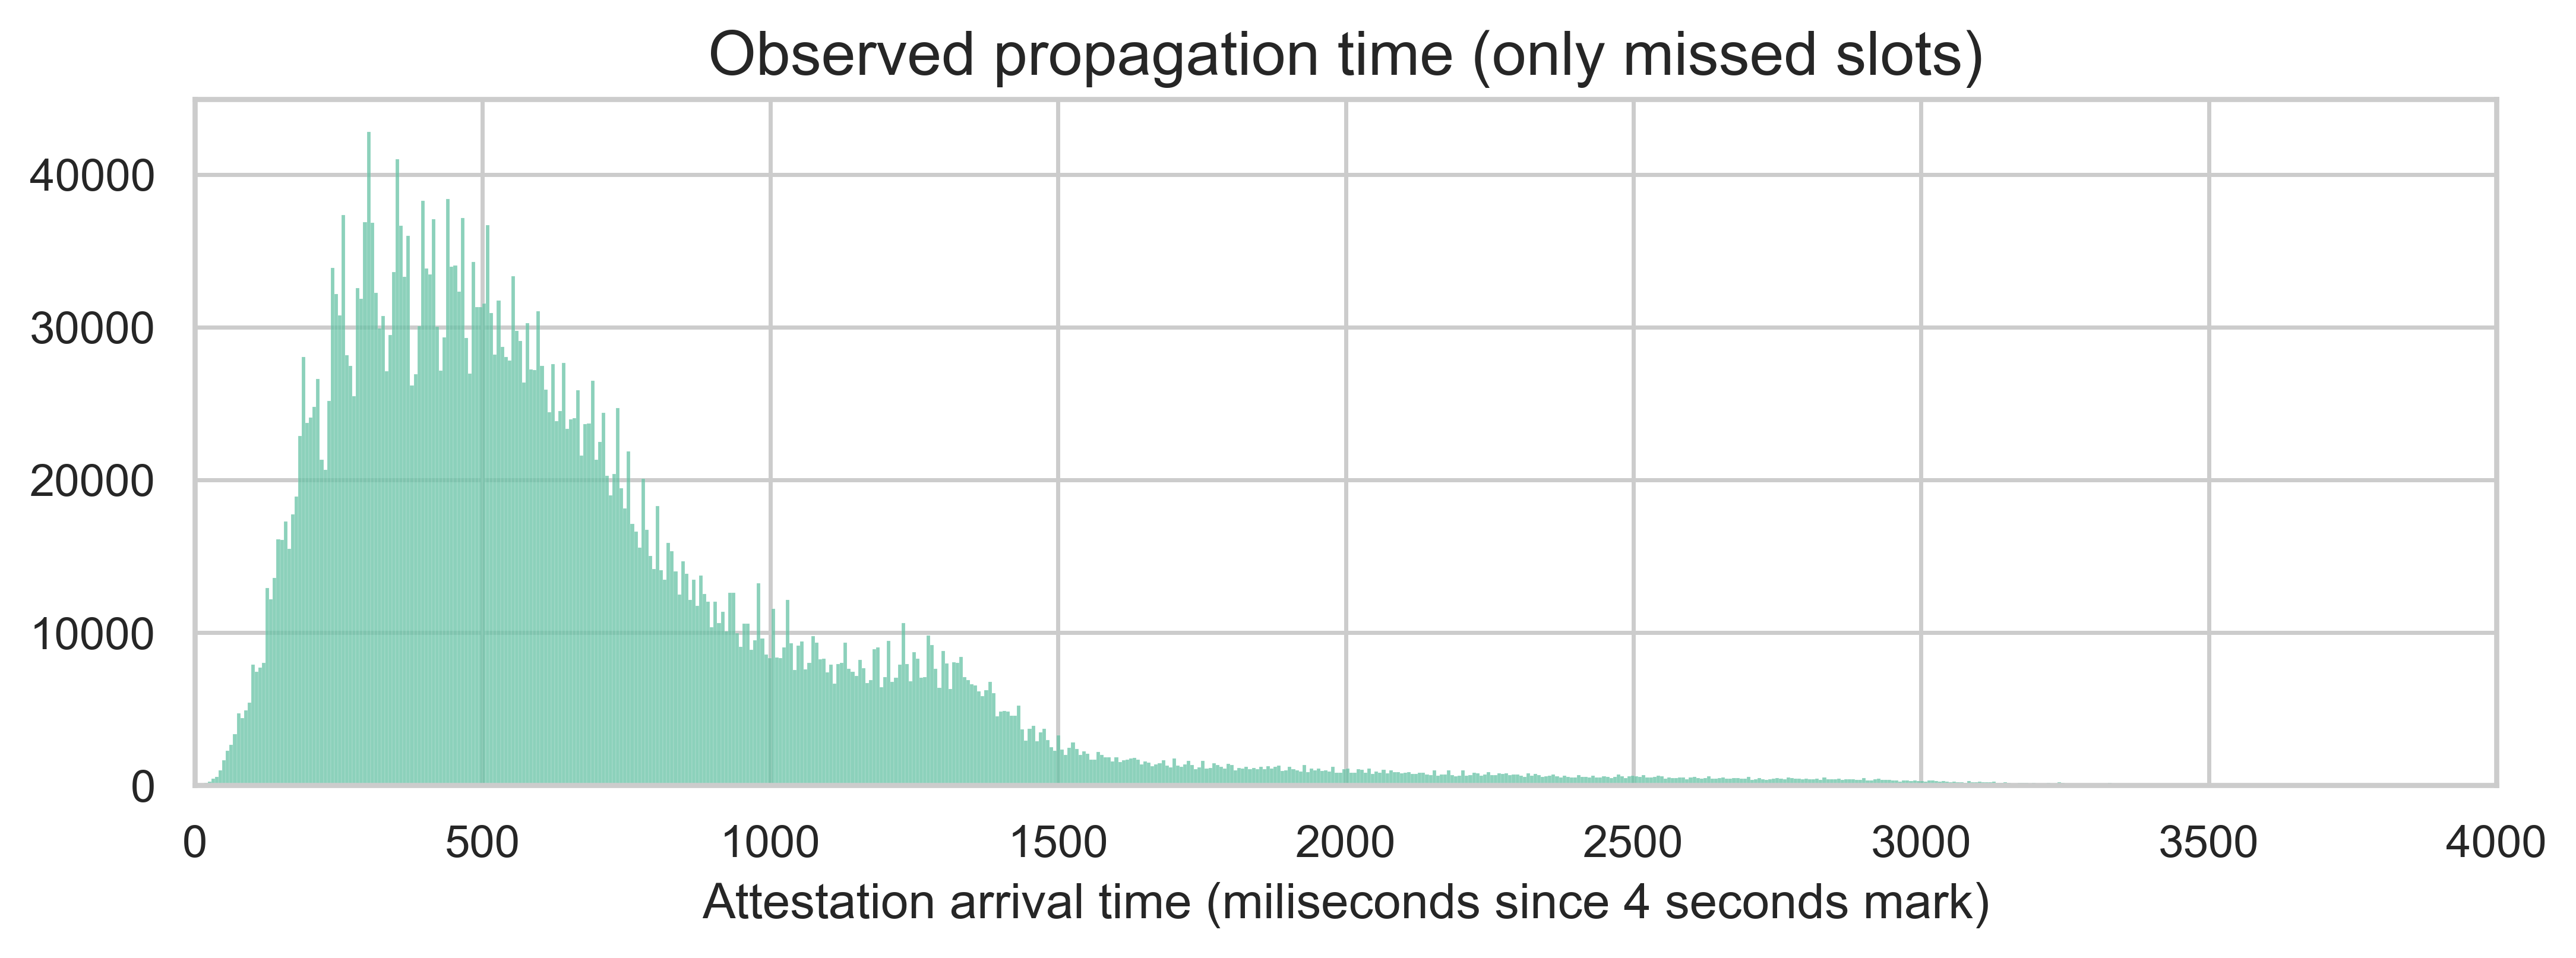

In [14]:
plt.figure(figsize=(10, 3))
sns.histplot(data=df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [15]:
df["atts_prop_time_ms"].agg(["mean", "std"])

mean    681.128850
std     490.366512
Name: atts_prop_time_ms, dtype: float64

In [16]:
df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     354.0
0.50     557.0
0.66     719.0
0.75     858.0
0.95    1535.0
0.99    2602.0
Name: atts_prop_time_ms, dtype: float64

#### Per beacon node

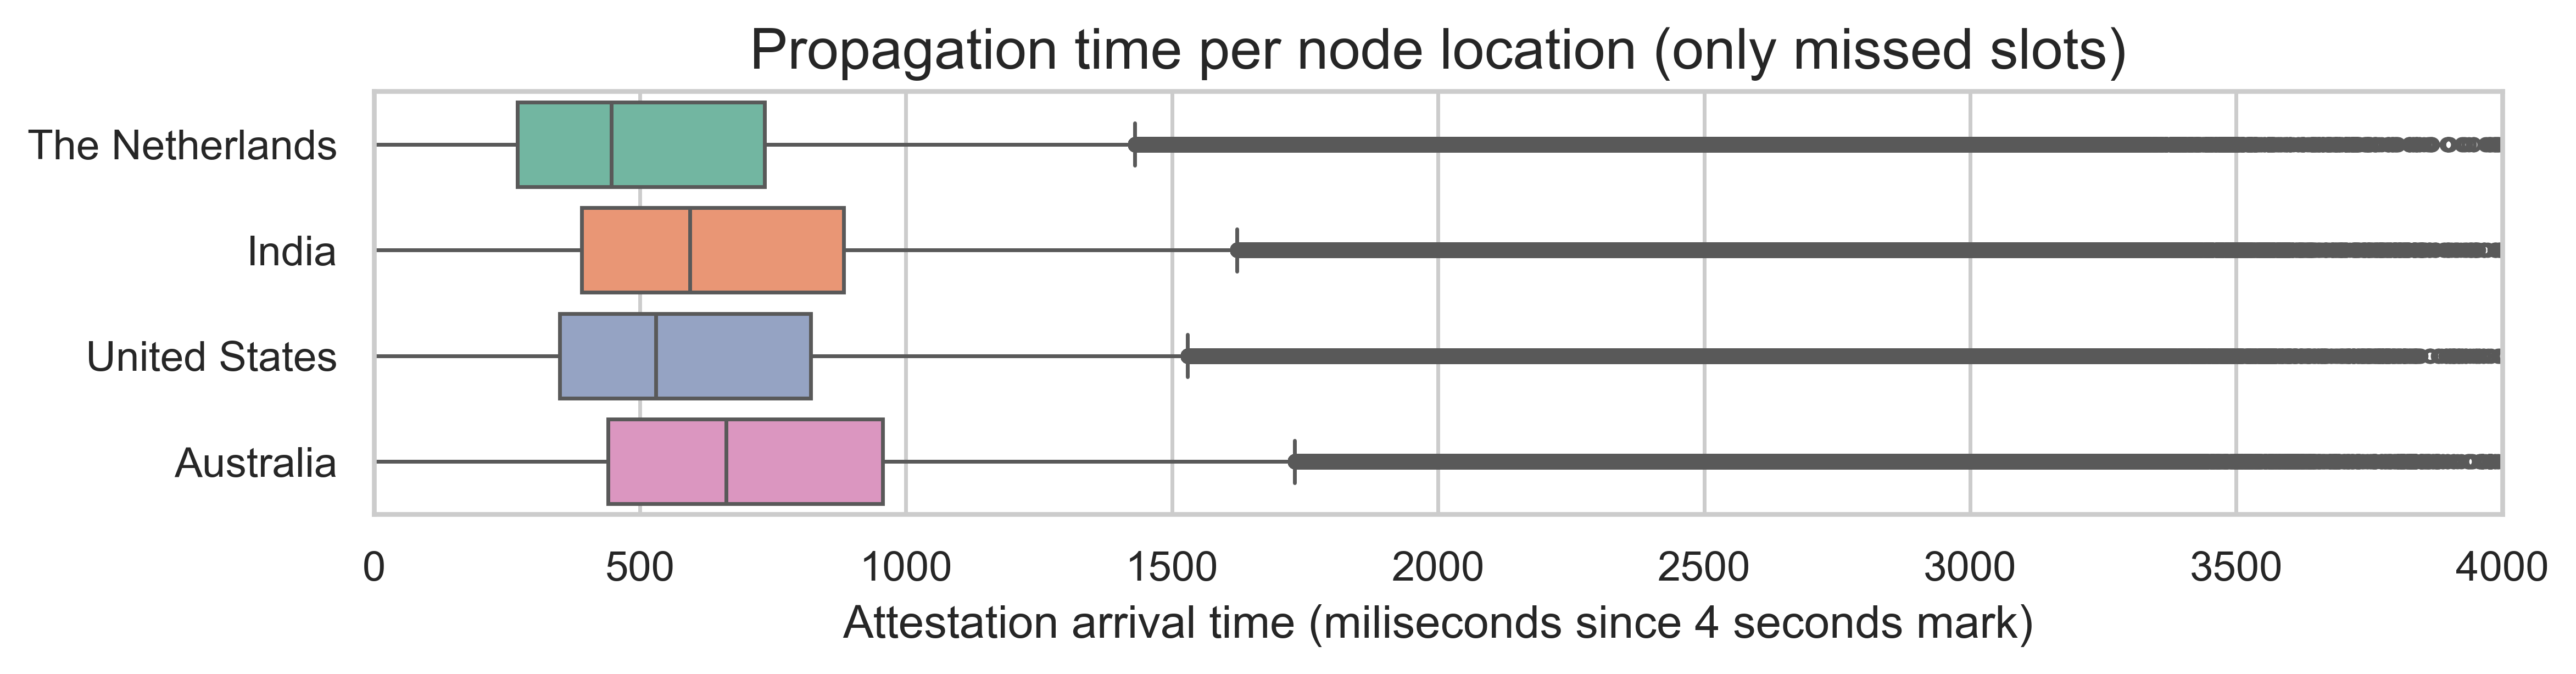

In [17]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="atts_prop_time_ms",
    y="node_country",
    hue="node_country",
    legend=False,
    fliersize=3
)
plt.xlim(0,4000)
plt.title("Propagation time per node location (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [18]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.66)

node_country
Australia          818.0
India              748.0
The Netherlands    597.0
United States      683.0
Name: atts_prop_time_ms, dtype: float64

In [19]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.95)

node_country
Australia          1648.0
India              1538.0
The Netherlands    1428.0
United States      1523.0
Name: atts_prop_time_ms, dtype: float64

#### Per attester entity

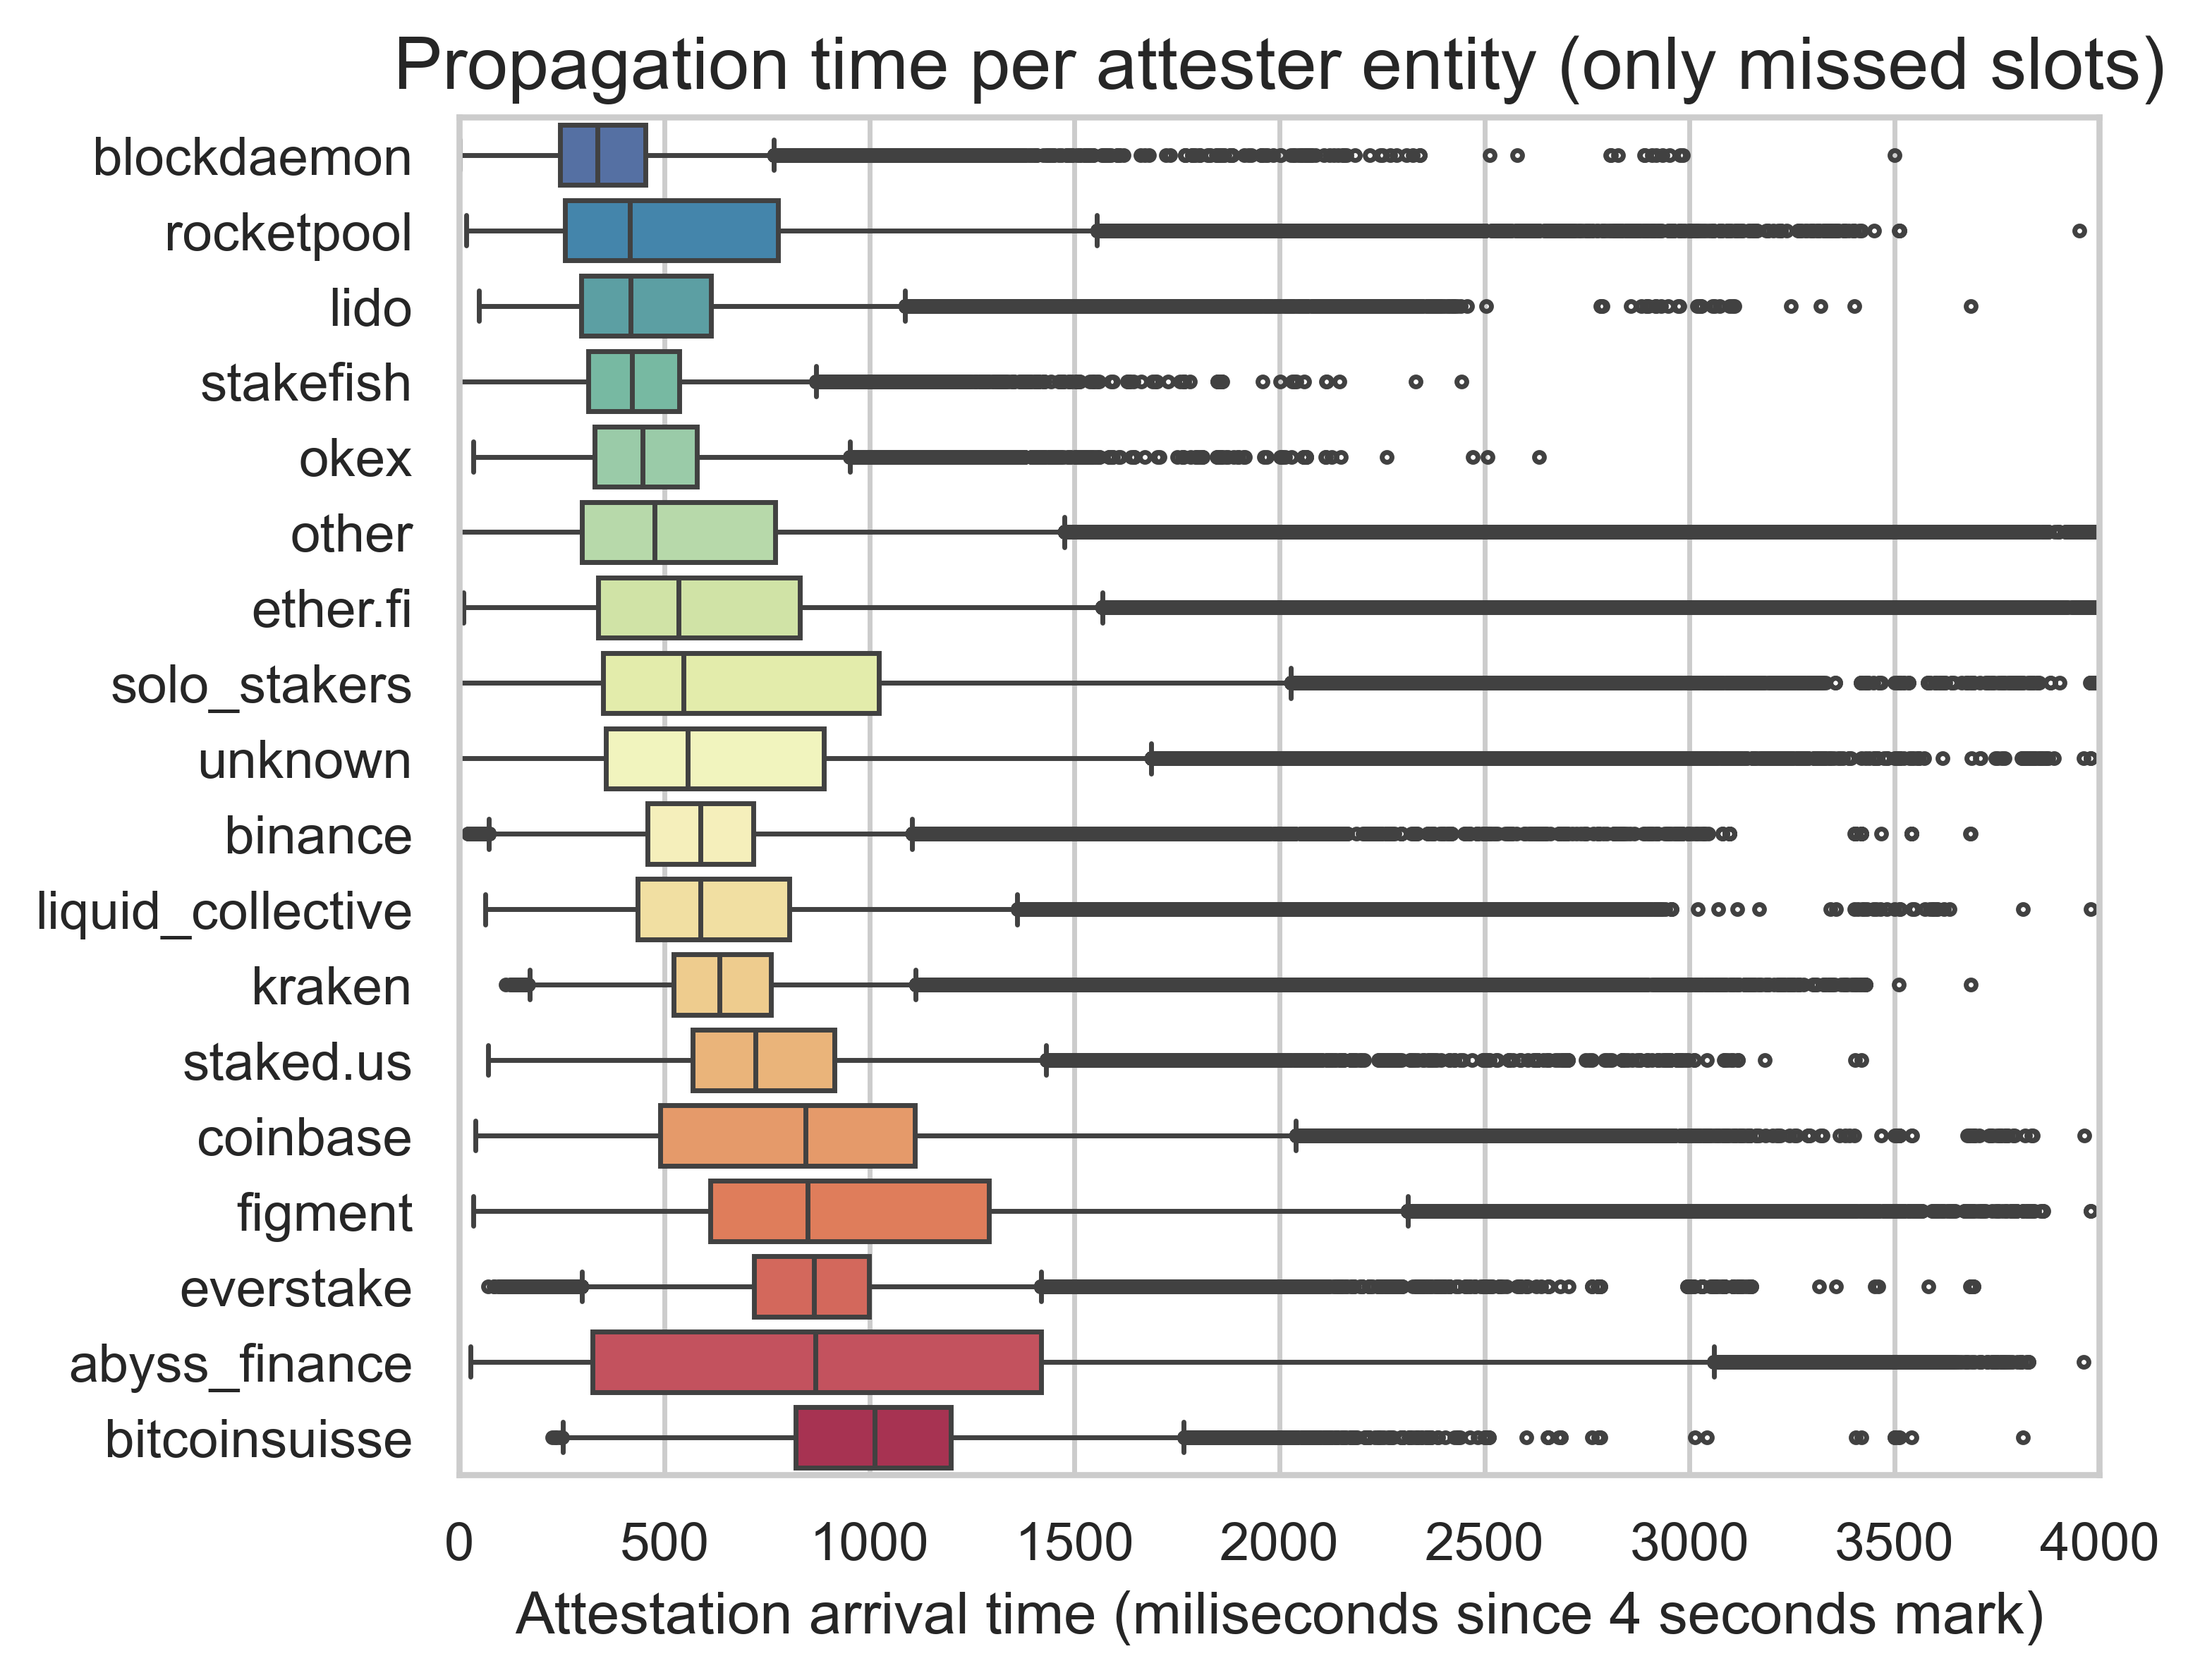

In [20]:
median_df = (
    df.groupby("entity")["atts_prop_time_ms"]
    .median()
    .reset_index()
    .rename(columns={"atts_prop_time_ms": "median"})
)
temp_df = df.merge(median_df, on="entity", how="left").sort_values("median")

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="entity",
    hue="entity",
    legend=False,
    palette="Spectral_r",
    fliersize=2
)
plt.xlim(0,4000)
plt.title("Propagation time per attester entity (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

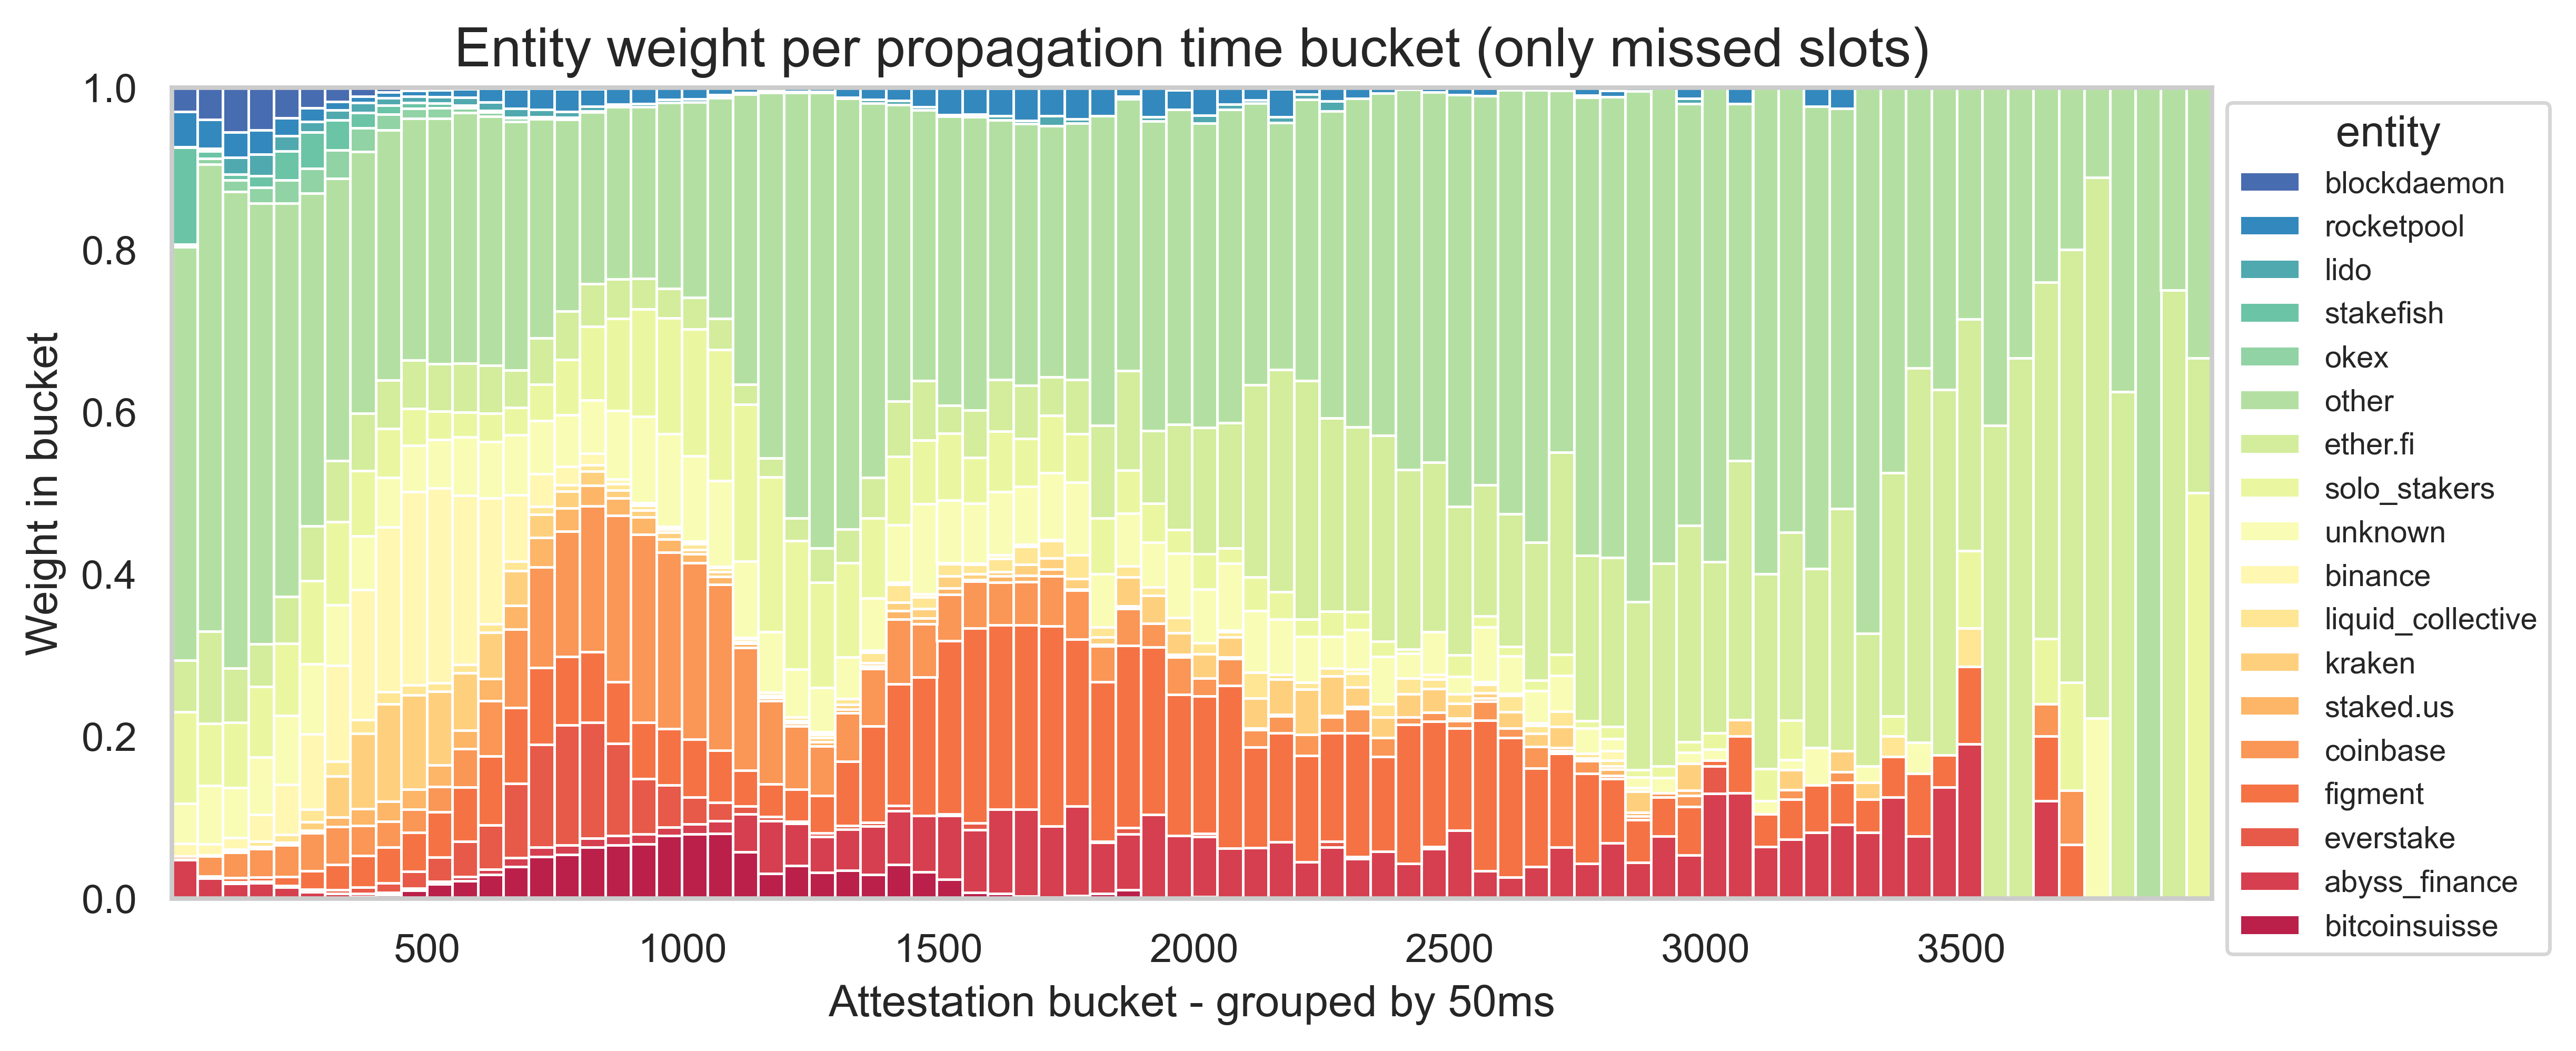

In [21]:
temp_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .merge(median_df, on="entity", how="left")
    .sort_values("median")
)
temp_df = temp_df[temp_df["atts_prop_time_ms"].between(0,4000)]
plt.figure(figsize=(10, 4))
ax = sns.histplot(
    data=temp_df,
    x="atts_prop_time_ms",
    hue="entity",
    multiple="fill",
    palette="Spectral_r",
    alpha=1,
    bins=80
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize='x-small')
plt.title("Entity weight per propagation time bucket (only missed slots)")
plt.ylabel("Weight in bucket")
plt.xlabel("Attestation bucket - grouped by 50ms")
plt.show()

#### Min across nodes

In [22]:
min_df = df.groupby(["slot", "atts_validator"])["atts_prop_time_ms"].min().reset_index()

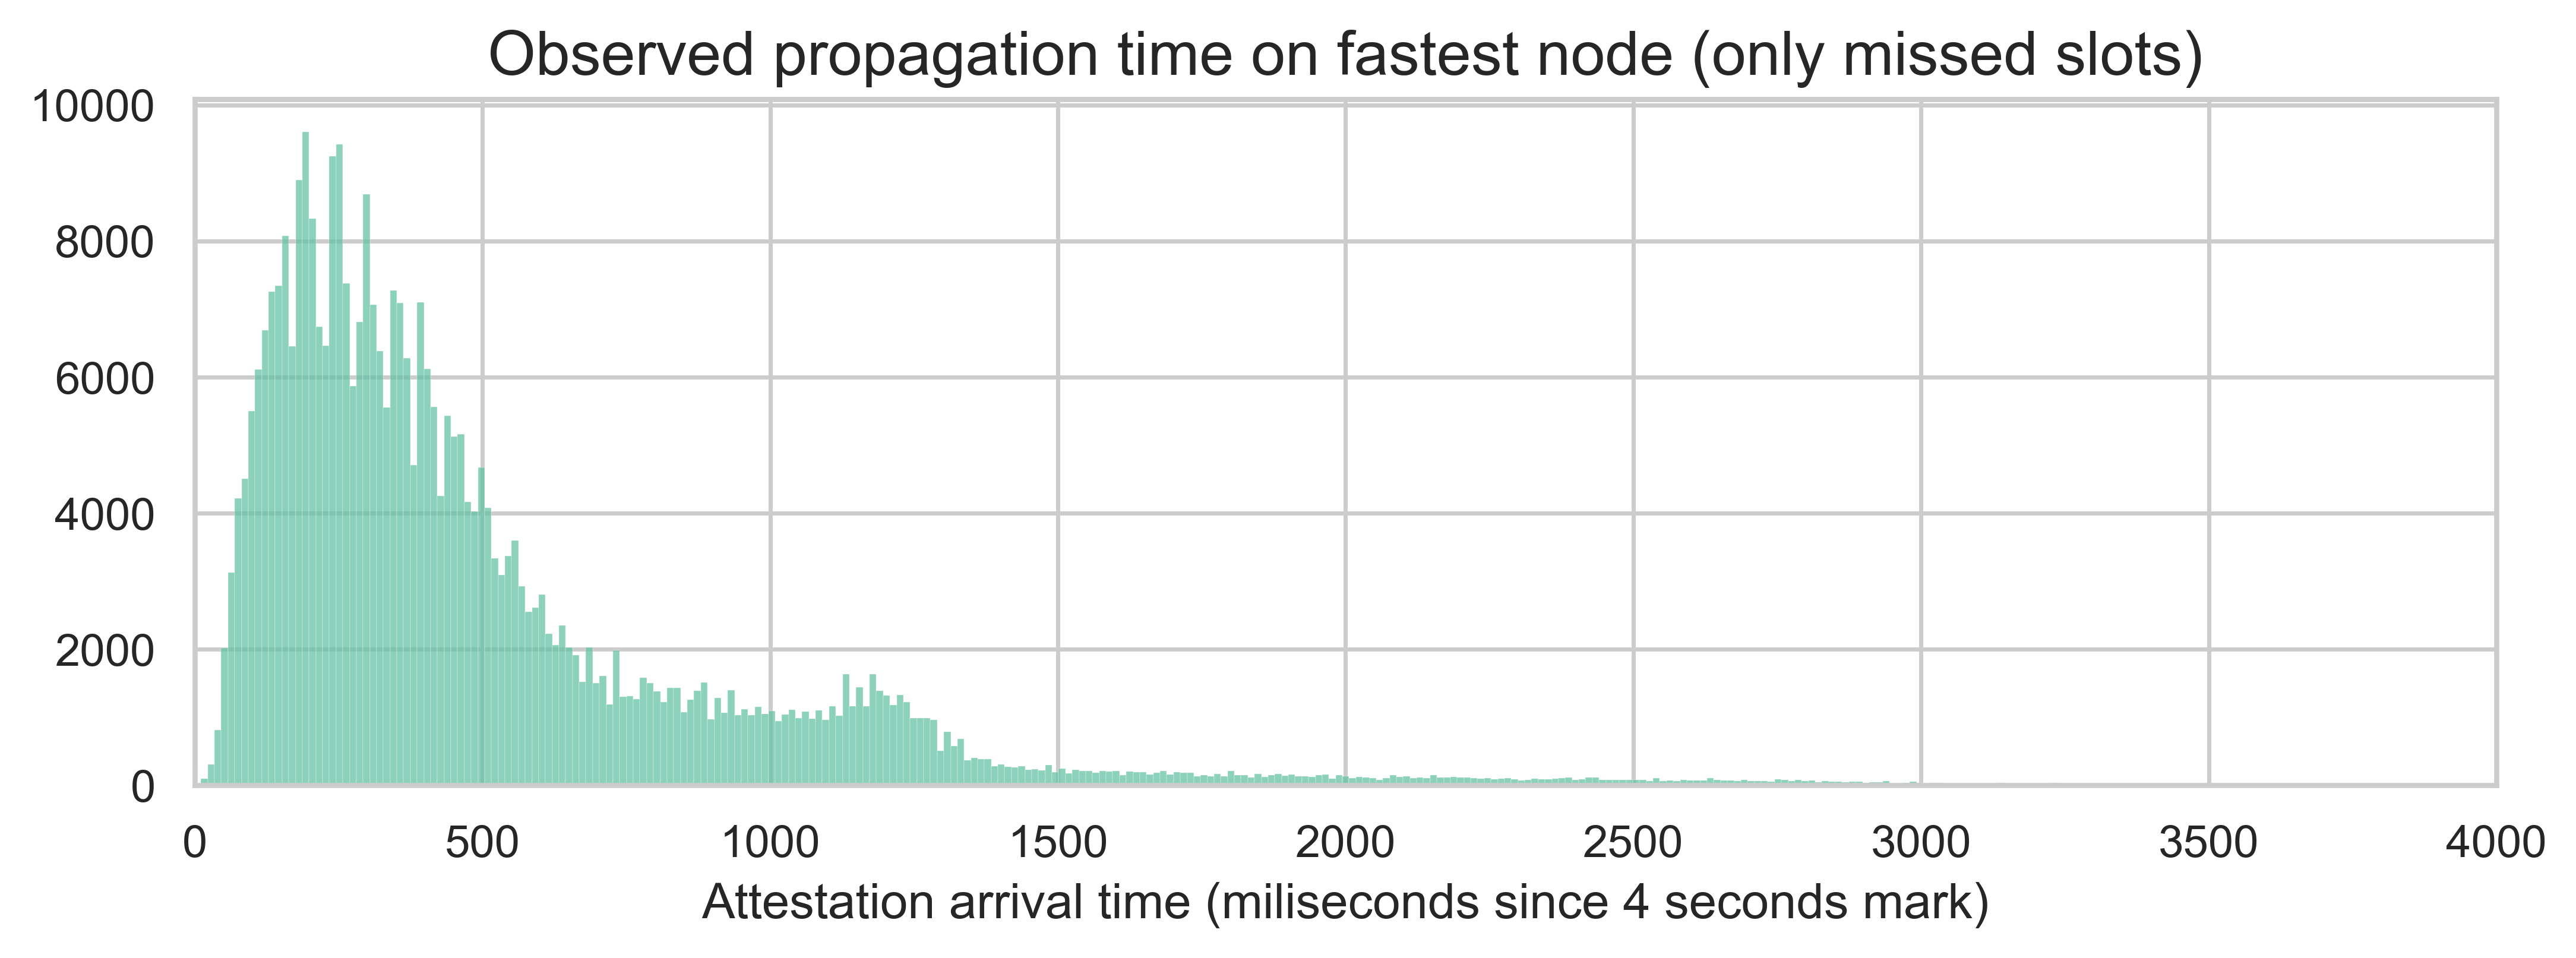

In [23]:
plt.figure(figsize=(10, 3))
sns.histplot(data=min_df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time on fastest node (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [24]:
min_df["atts_prop_time_ms"].agg(["mean", "std"])

mean    521.831515
std     481.734335
Name: atts_prop_time_ms, dtype: float64

In [25]:
min_df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     216.0
0.50     368.0
0.66     505.0
0.75     639.0
0.95    1361.0
0.99    2497.0
Name: atts_prop_time_ms, dtype: float64

## 4. Distribution on subnet

In [26]:
agg_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .groupby(["slot", "atts_subnet"])["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_2": "Percentile"})
)

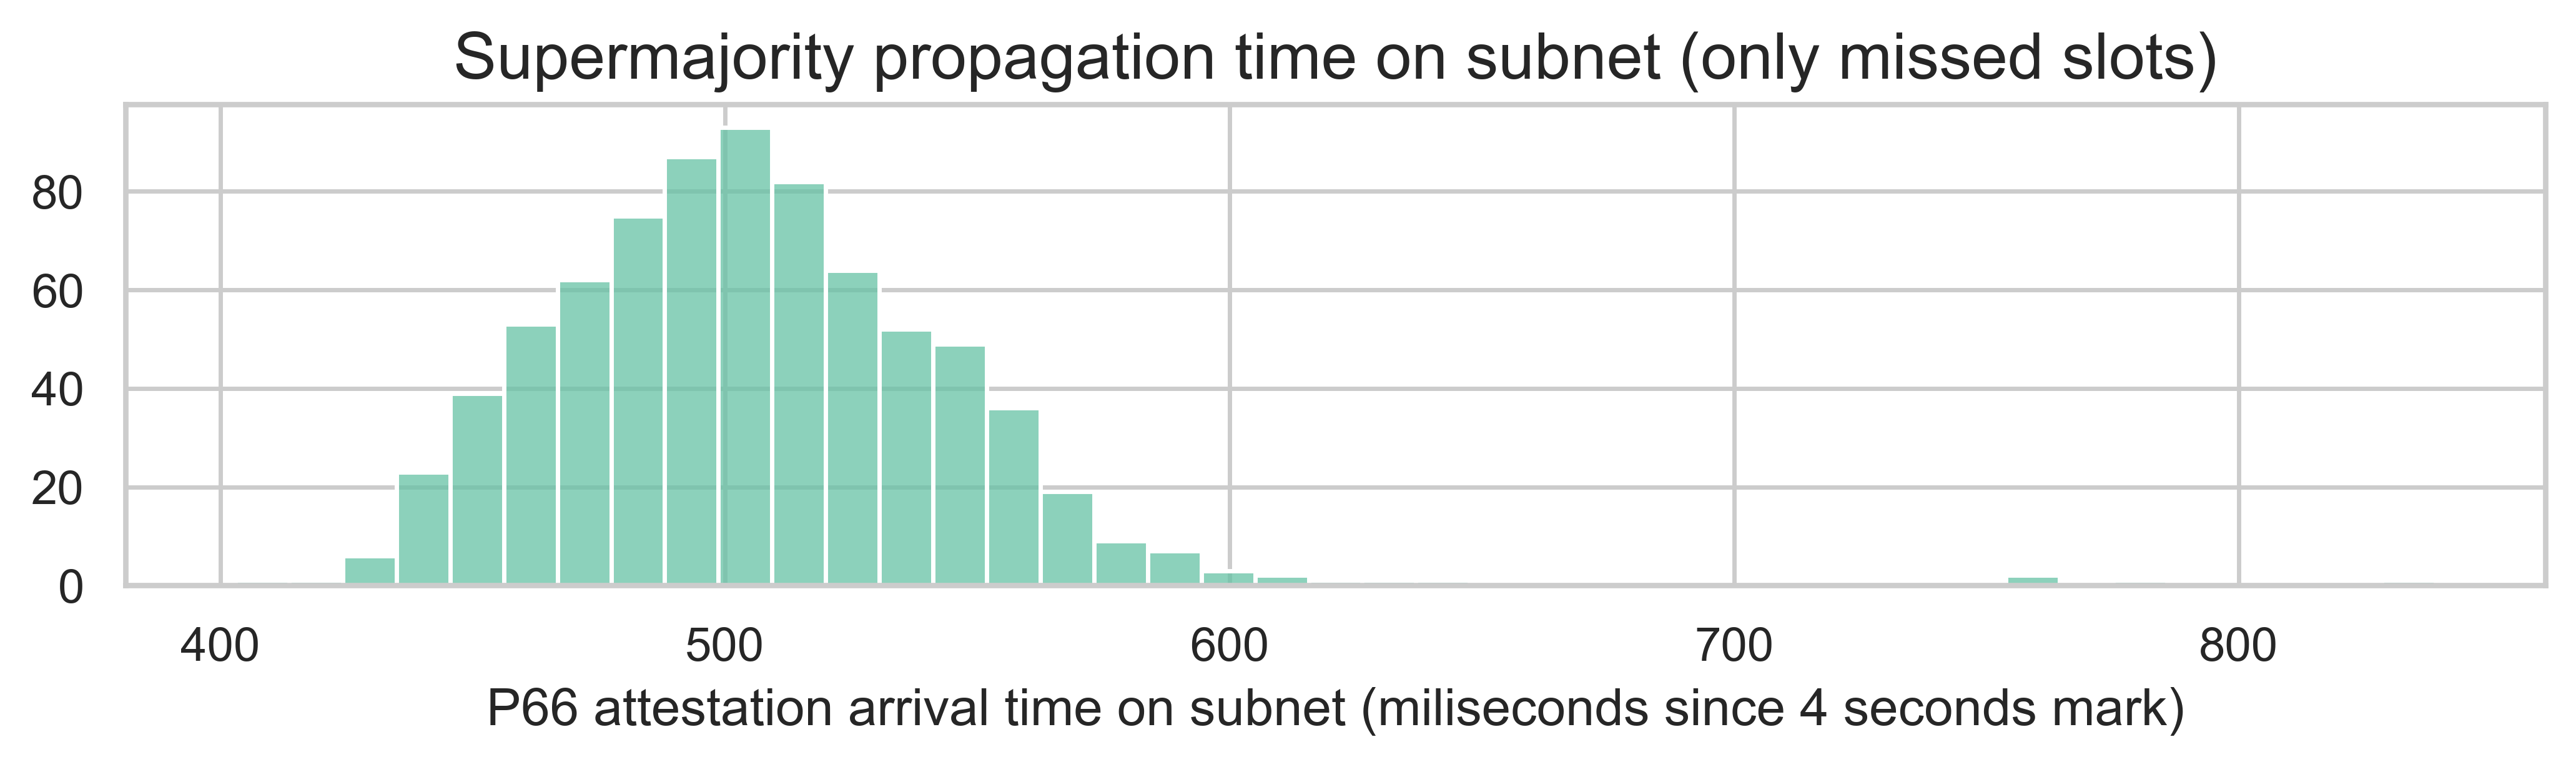

In [27]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.66], x="atts_prop_time_ms")
plt.title("Supermajority propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P66 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

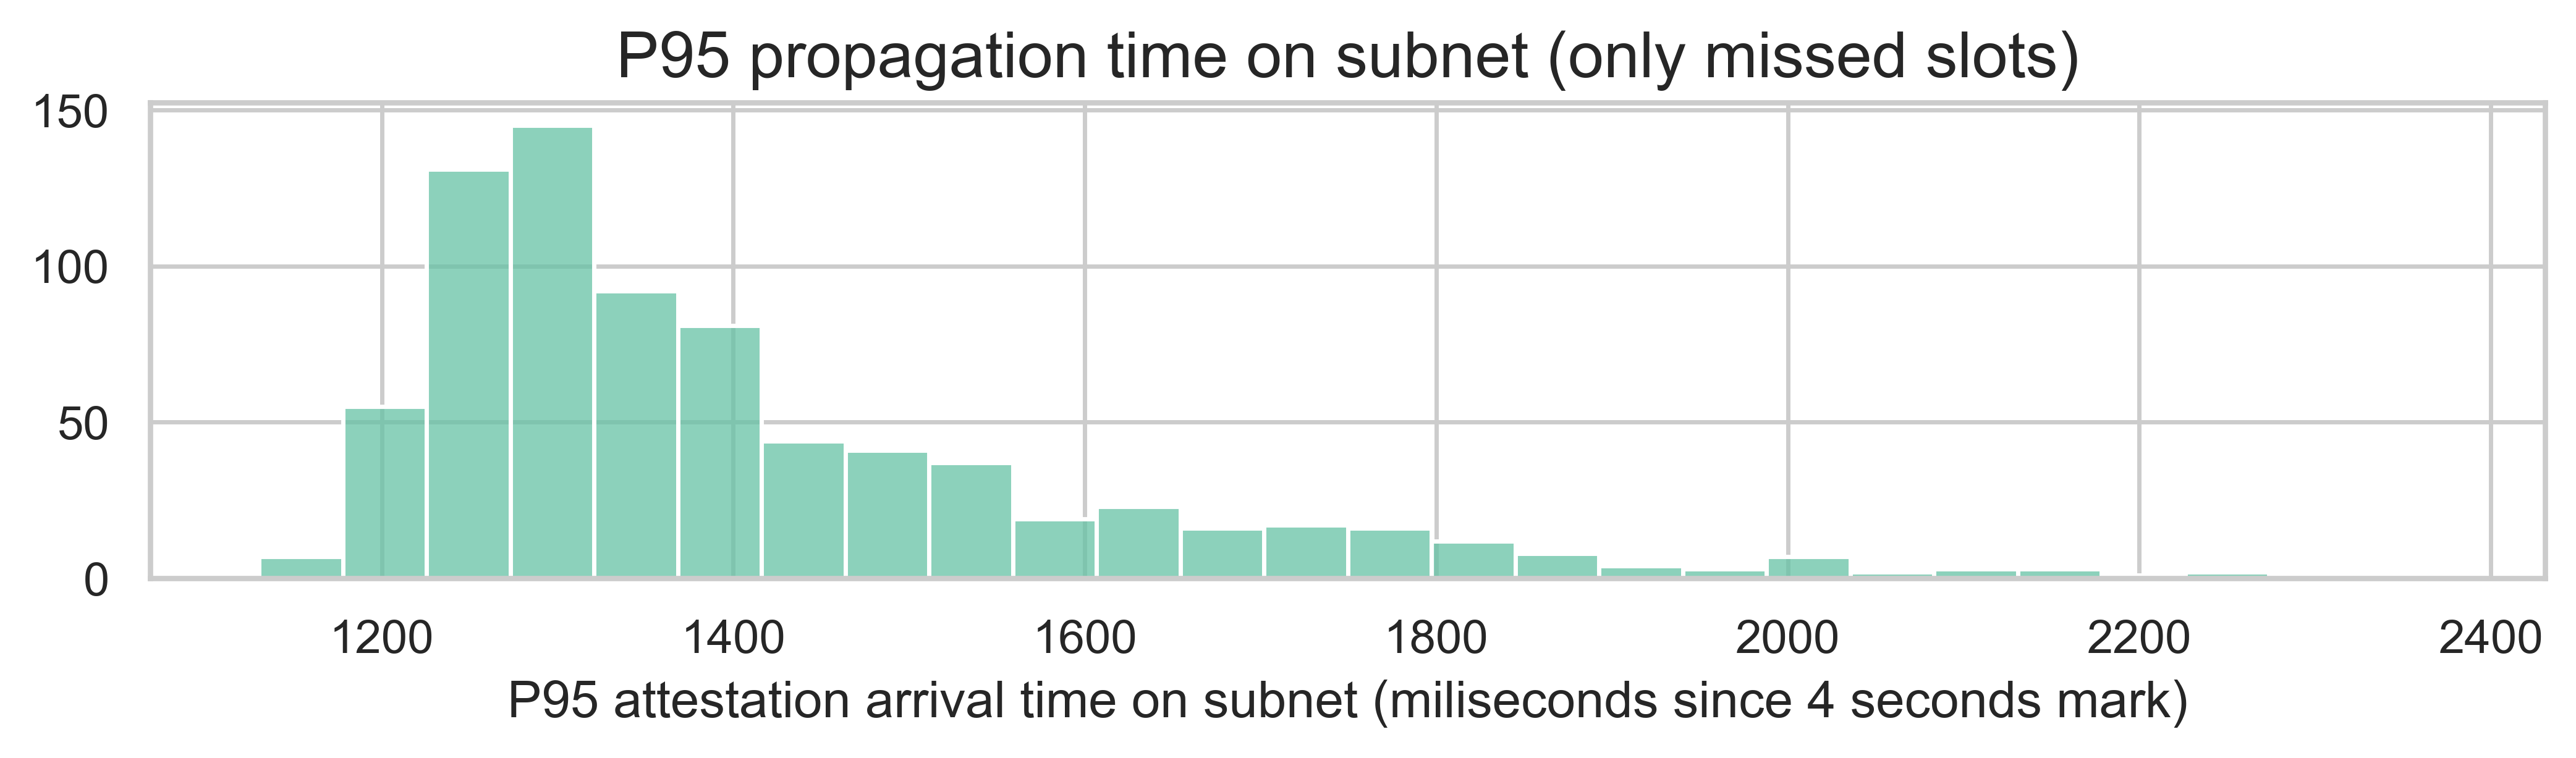

In [28]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.95], x="atts_prop_time_ms")
plt.title("P95 propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P95 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

In [29]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].quantile(0.95)

Percentile
0.66     566.642
0.95    1831.065
Name: atts_prop_time_ms, dtype: float64

In [30]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].max()

Percentile
0.66     839.0
0.95    2369.0
Name: atts_prop_time_ms, dtype: float64

In [31]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].mean()

Percentile
0.66     505.722805
0.95    1410.958571
Name: atts_prop_time_ms, dtype: float64

## 5. Example CDFs

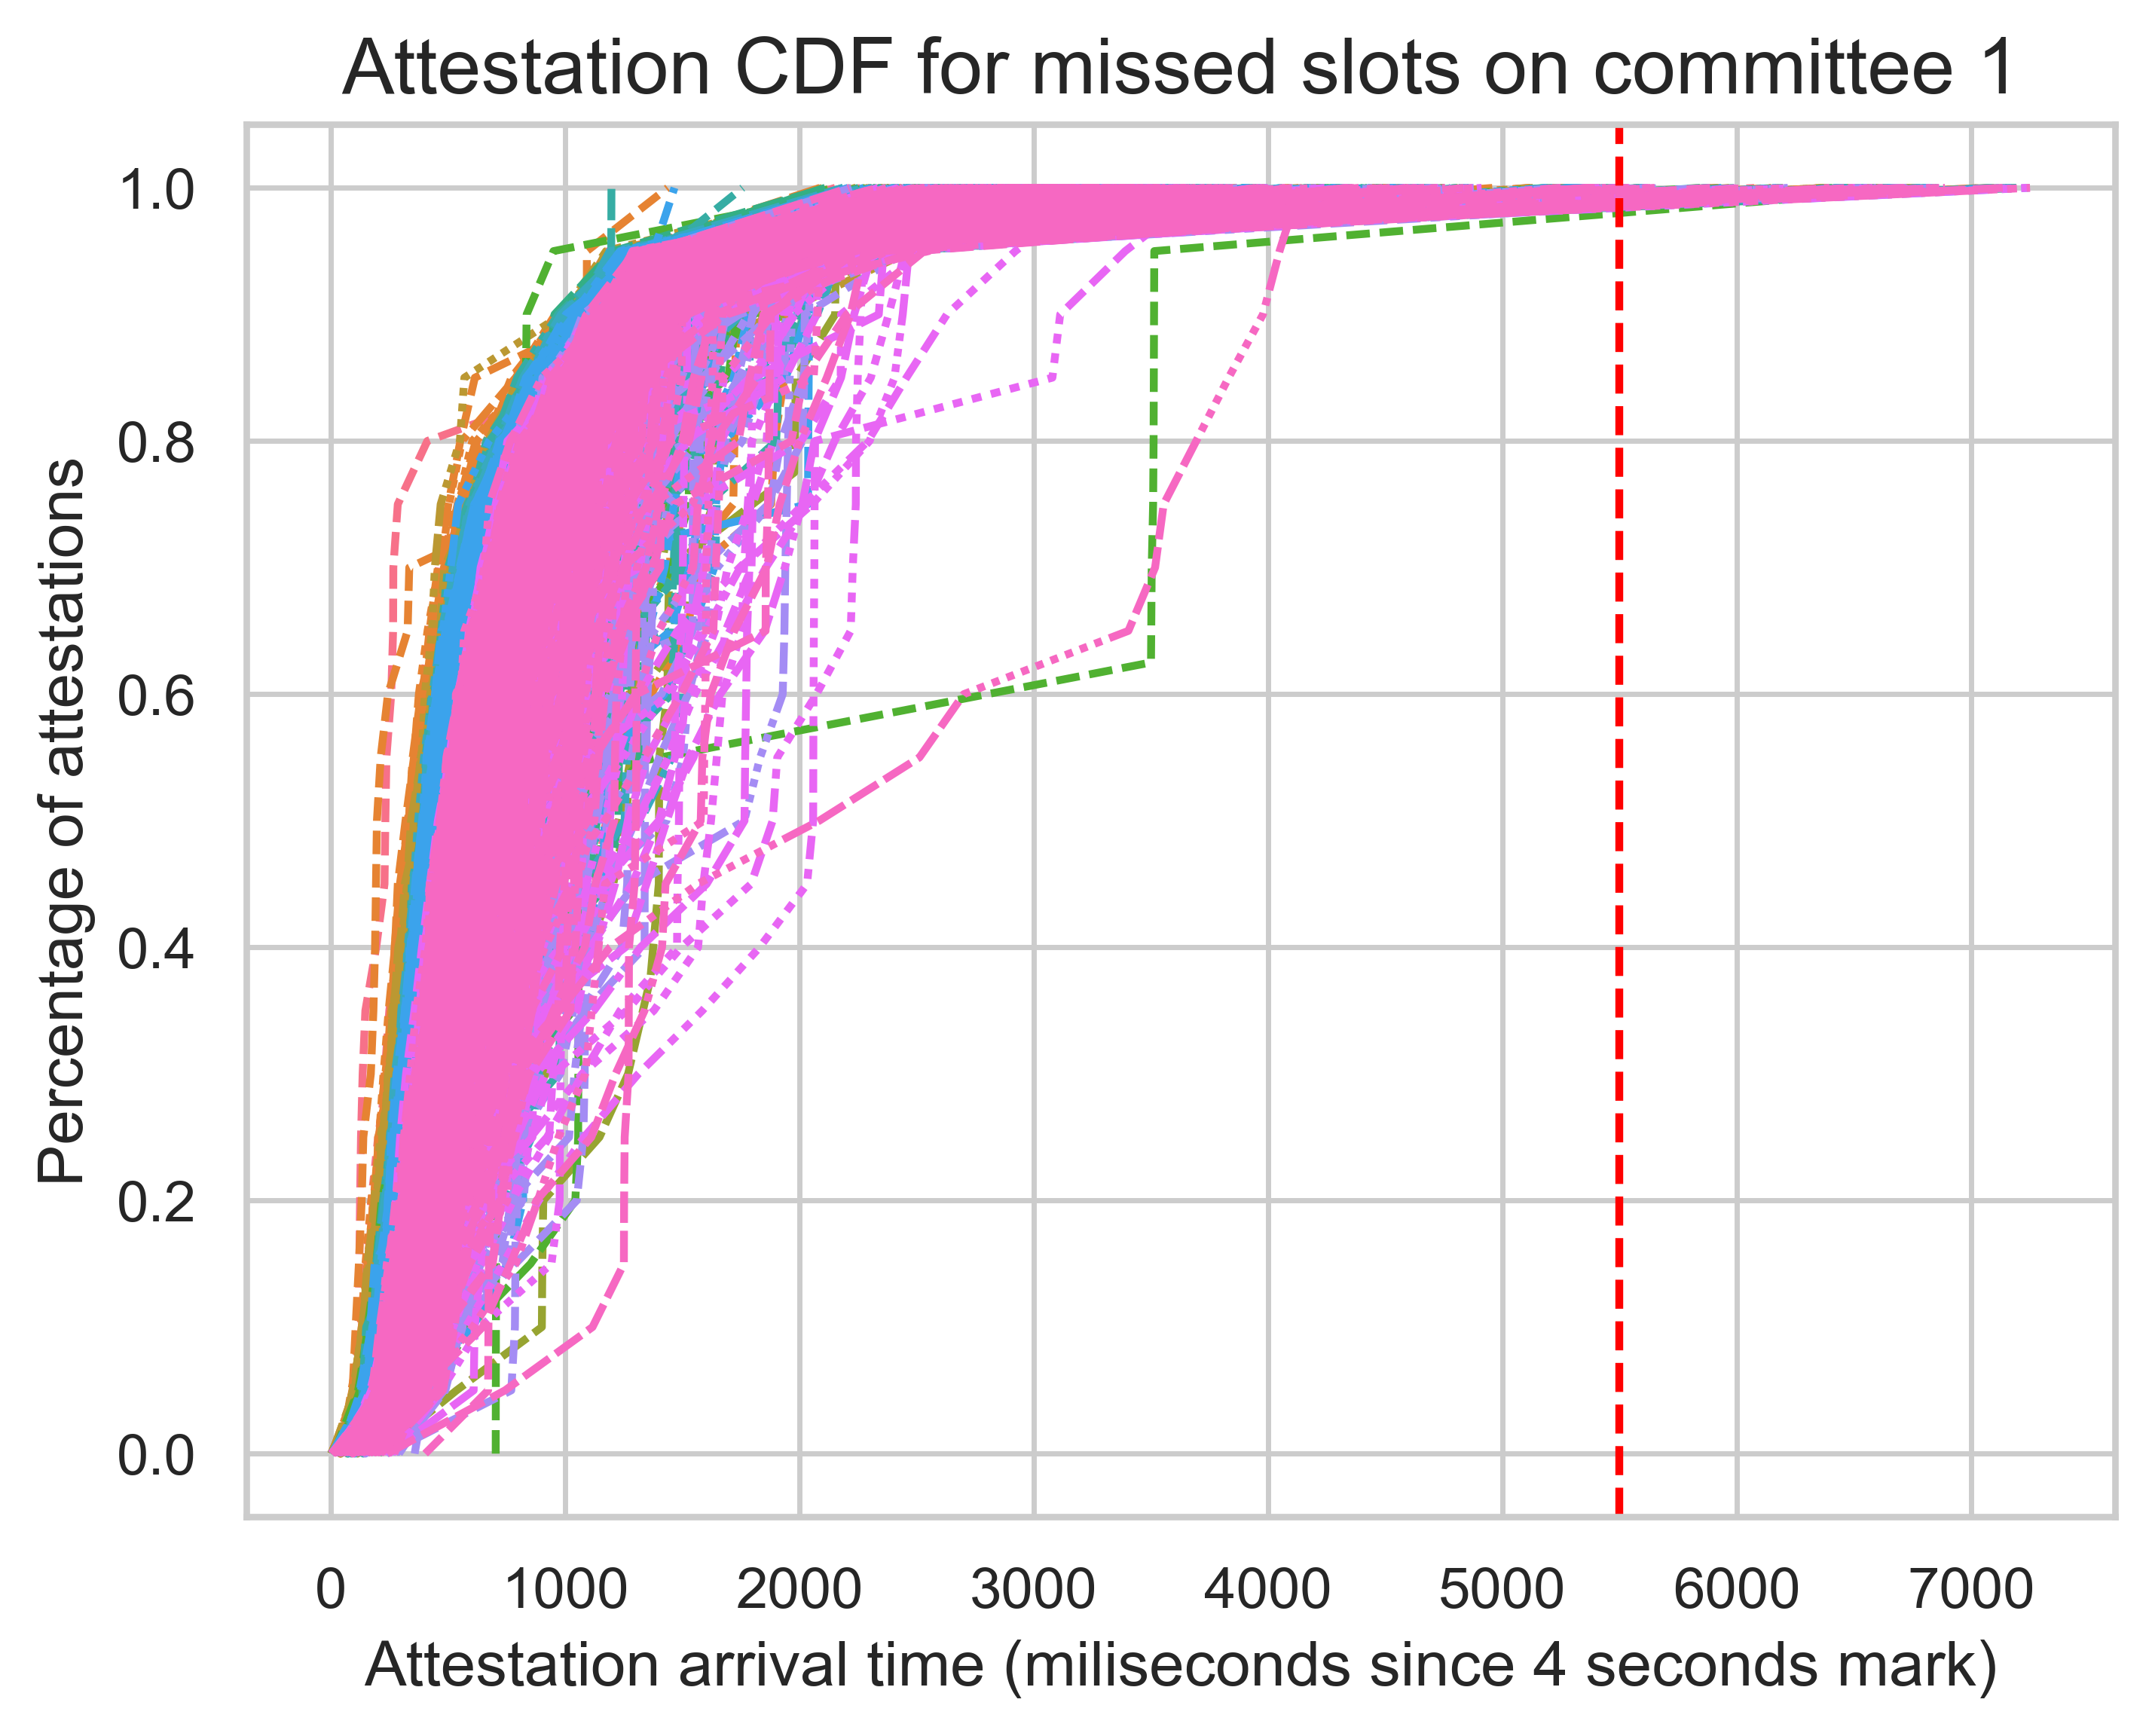

In [32]:
temp_df = df[(df["atts_prop_time_ms"] > 0) & (atts_df["atts_subnet"] == "1")].copy()
temp_df = (
    temp_df.groupby(["node_name", "slot"])["atts_prop_time_ms"]
    .quantile(np.arange(0, 1.05, 0.05))
    .reset_index()
)
temp_df.columns = ["node_name", "slot", "percentile", "attes_time"]

ax = sns.lineplot(
    temp_df,
    x="attes_time",
    y="percentile",
    hue="node_name",
    style="slot",
    errorbar=None,
    legend=False,
)
plt.axvline(x=5500, color="red", linestyle="dashed")
plt.title("Attestation CDF for missed slots on committee 1")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.ylabel("Percentage of attestations")
plt.show()

In [33]:
temp_df.groupby("percentile")["attes_time"].mean().head(25)

percentile
0.00      87.136268
0.05     199.278546
0.10     250.696576
0.15     293.091160
0.20     332.163802
0.25     373.504950
0.30     412.836525
0.35     451.156976
0.40     488.270580
0.45     524.493338
0.50     560.961332
0.55     599.503506
0.60     641.552760
0.65     687.334428
0.70     741.575076
0.75     815.647624
0.80     926.317307
0.85    1079.095970
0.90    1258.247426
0.95    1520.768309
1.00    3339.671092
Name: attes_time, dtype: float64